### Imports

In [ ]:
import nevergrad as ng
import numpy as np
from matplotlib import pyplot as plt
np.set_printoptions(legacy='1.25')
from classes import Stock, Portfolio, PortfolioOptimizer
from portfolio_utils import *
import random
import seaborn as sns

Let's increase the size of the universe to a much larger number of stocks.

In [17]:
stocks = [Stock("AAPL", "Apple"), Stock("MSFT", "Microsoft"), Stock("AMZN", "Amazon"), Stock("NVDA", "Nvidia"), Stock("GOOG", "Alphabet")]

In [18]:
weights = [0.2] * len(stocks)
portfolio = Portfolio(stocks, weights)

In [ ]:
prices = fetch_prices(portfolio.stocks, "2022-01-01", "2024-12-31", interval="1mo")
rets = returns(prices, "arith")
cov = rets.cov() 	# Covariance of returns
tickers = [s.ticker for s in portfolio.stocks]
ex_rets = expected_return(rets)

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/utils.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(


In [28]:
class MultiOptimizer(PortfolioOptimizer):

	def optimize(self, returns, covar, tickers):
		def objective(weights):
			return multiobjective(weights, returns, covar)

		init_weights = [1.0/len(tickers)] * len(tickers)

		optimizer = ng.optimizers.NgIoh(parametrization=ng.p.Array(init=init_weights, lower = 0, upper = 1, mutable_sigma=True), budget=100000)
		optimizer.minimize(objective)
		return optimizer

In [29]:
m = MultiOptimizer()

In [30]:
optimizer = m.optimize(rets.values, cov, tickers)

/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: BadLossWarning: Updating fitness with inf value
  warnings.warn(msg, e)
/mnt/G/Rnd/Coding_Stuff/MSML610/umd_classes/class_project/MSML610/Fall2025/Projects/UmdTask61_Fall2025_nevergrad_Multi_Objective_Optimization_for_Portfolio_Management/.venv/lib/python3.12/site-packages/nevergrad/optimization/base.py:149: LossTooLargeWarning: Clipping very high value inf in tell (rescale the cost function?).
  warnings.warn(msg, e)


In [31]:
pf = optimizer.pareto_front()
pts = [(x.value[0], x.value[1]) for x in pf]
pts_x = [x for (x, _) in pts]
pts_y = [y for (_, y) in pts]

Since we only have two objectives, we can again plot our frontier and see how it looks.

In [32]:
x = []
y = []
z = []
for i in range(100000):
    w = np.array([random.random() for _ in range(5)])
    w /= w.sum()
    ret = portfolio_return(w, rets.values)
    var = portfolio_variance(w, cov)
    loss = sum(multiobjective(w, ret, cov))
    x.append(ret)
    y.append(np.sqrt(var))
    z.append(loss)

df = pd.DataFrame(data = None)
df["Return"] = x
df["Std"] = y
df["Loss"] = z

In [33]:
pf_x = []
pf_y = []
pf_z = []
for i in pf:
    weights = np.array(i.value)
    weights /= weights.sum()
    ret = portfolio_return(weights, rets.values)
    var = portfolio_variance(weights, cov)
    loss = sum(multiobjective(weights, ret, cov))
    pf_x.append(ret)
    pf_y.append(np.sqrt(var))
    pf_z.append(loss)
    
pf_data = pd.DataFrame(data=None)
pf_data["Return"] = pf_x
pf_data["Std"] = pf_y
pf_data["Loss"] = pf_z

<Axes: xlabel='Std', ylabel='Return'>

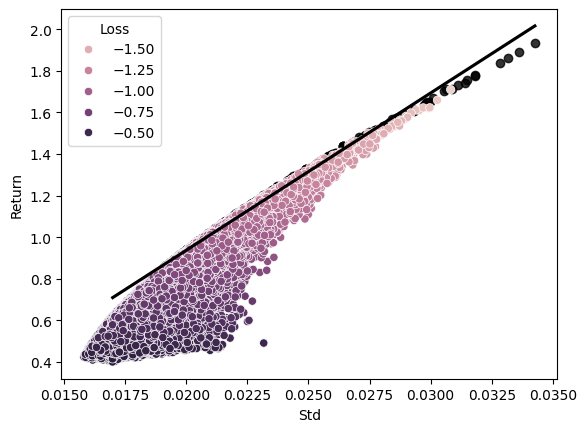

In [34]:
ax = sns.regplot(data=pf_data, y="Return", x="Std", color="black", fit_reg=True, ci=None, robust=True)
sns.scatterplot(data=df, y="Return", x="Std", hue="Loss", ax=ax)